In [23]:
# 1. Data Manipulation & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Distributions & MLE (Normal, Binomial, Poisson)
from scipy import stats
from scipy.optimize import minimize

# 3. Hypothesis Testing & Proportions
# (T-tests, Z-tests, Proportion tests)
from statsmodels.stats.weightstats import ttest_ind, ztest
from statsmodels.stats.proportion import proportions_ztest

# 4. Non-Parametric Tests (Self-Study)
# (Mann-Whitney, Wilcoxon, Kruskal-Wallis)
from scipy.stats import mannwhitneyu, wilcoxon, kruskal

# 5. ANOVA & MANOVA
# import statsmodels.api as smf
import statsmodels.formula.api as smf
from statsmodels.multivariate.manova import MANOVA

# 6. Linear & Logistic Regression
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 7. Model Validation & Preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, mean_squared_error

print("✅ All statistical libraries loaded successfully!")

✅ All statistical libraries loaded successfully!


In [2]:
# bayes therom Q1a.

num = (0.3 * 0.03) + (0.45 * 0.05) + (0.25 * 0.02)
de = 0.45 * 0.05

ans = de / num
ans

0.6164383561643837

In [3]:
#Q1c.

import numpy as np

alpha = 0.05
std = 0.5
mu = 1.8
xbar = 1.6
n = 50

se = std / np.sqrt(n)
z_calc = (xbar - mu) / se
print(f"z calc: {z_calc}")

#zpos

zneg = stats.norm.ppf(alpha/2)
zpos = stats.norm.ppf(1 - alpha/2)

print(f"{zneg} ----- {z_calc} ---- {zpos}")

#reject H0 and accept H1

z calc: -2.8284271247461894
-1.9599639845400545 ----- -2.8284271247461894 ---- 1.959963984540054


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic customer data
n_samples = 500

age = np.random.normal(loc=35, scale=10, size=n_samples)

income = np.random.normal(loc=60000, scale=15000, size=n_samples)

web_activity = np.random.uniform(0, 10, size=n_samples)

# Generate purchase decision (target variable) based on realistic factors
probability = 1 / (
    1 + np.exp(
        -(-3 + 0.05 * age + 0.00003 * income + 0.3 * web_activity)
    )
)

purchase = (np.random.rand(n_samples) < probability).astype(int)

# Create a DataFrame
df = pd.DataFrame({
    'Age': age,
    'Income': income,
    'Web_Activity': web_activity,
    'Purchased': purchase
})


In [5]:
df.columns

Index(['Age', 'Income', 'Web_Activity', 'Purchased'], dtype='object')

In [6]:
# cont: 'Age', 'Income', 'Web_Activity'

In [7]:
scaler = StandardScaler()
df[['Age', 'Income', 'Web_Activity']] = scaler.fit_transform(df[['Age', 'Income', 'Web_Activity']])

In [8]:
df.head()

,Age,Income,Web_Activity,Purchased
0,0.499735,0.915388,-1.156845,1
1,-0.148023,1.921755,-1.374304,1
2,0.653748,-1.464039,0.464022,1
3,1.546706,0.543637,0.706127,1
4,-0.245841,-0.698522,-1.626557,0


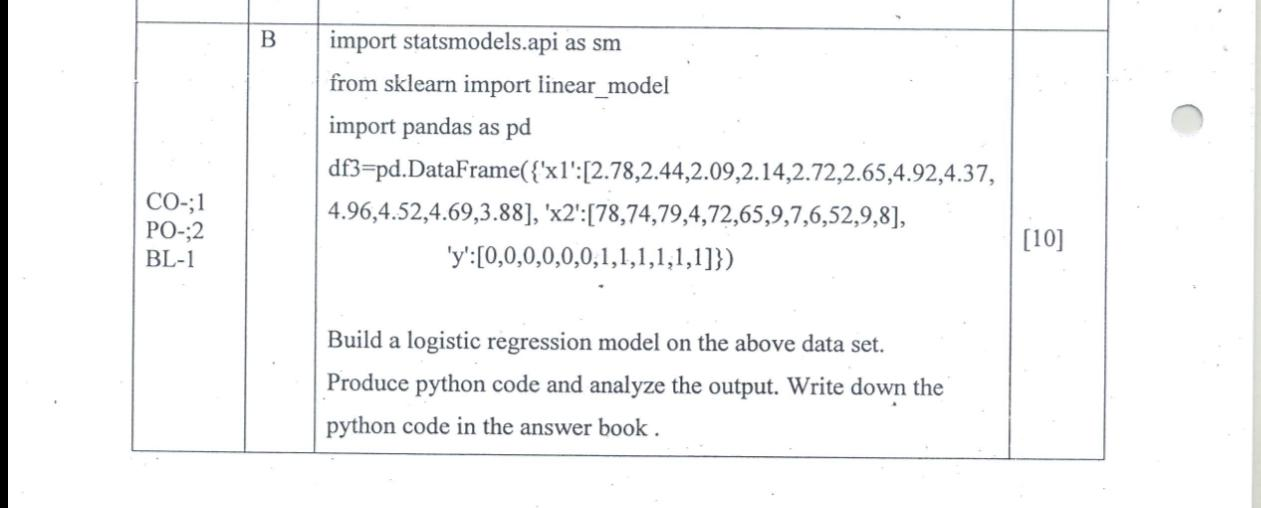

In [9]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df3 = pd.DataFrame({
    "x1": [2.78,2.44,2.09,2.14,2.72,2.65,4.92,4.37,4.96,4.52,4.69,3.88],
    "x2": [78,74,79,4,72,65,9,7,6,52,9,8],
    "y":  [0,0,0,0,0,0,1,1,1,1,1,1]
})

In [10]:
scaler = StandardScaler()
df3[["x1", "x2"]] = scaler.fit_transform(df3[["x1", "x2"]])

In [11]:
x = df3[["x1", "x2"]]
y = df3["y"]
x = add_constant(x)
vif = pd.DataFrame()
vif["Features"] = x.columns
vif["VIF"] = [variance_inflation_factor(x.values , i) for i in range(x.shape[1])]
vif

,Features,VIF
0,const,1.000000
1,x1,1.740938
2,x2,1.740938


In [12]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

In [14]:
alphas = 10**np.linspace(10,-2,100)*0.5

ridgecv = RidgeCV (alphas = alphas)
ridgecv.fit(x,y)
bestalphaR = ridgecv.alpha_ #best alpha
print(f"Ridge: {bestalphaR}")

lassocv = LassoCV(alphas=alphas)
lassocv.fit(x, y)
bestalphaL = lassocv.alpha_
print(f"Lasso: {bestalphaL}")

Ridge: 0.005
Lasso: 0.005


In [19]:
fitl = Lasso(alpha = bestalphaL)
fitl.fit(x, y)
fitl.coef_
print(pd.Series(fitl.coef_, index=x.columns))

const    0.000000
x1       0.414481
x2      -0.089171
dtype: float64


In [36]:
from sklearn.linear_model import LogisticRegression

x = df3[['x1', 'x2']]
y = df3['y']

from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, cros
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[1 1]
 [0 1]]
0.6666666666666666


In [26]:
df3

,x1,x2,y
0,-0.671440,1.227338,0
1,-0.982745,1.102788,0
2,-1.303205,1.258476,0
3,-1.257425,-1.076840,0
4,-0.726376,1.040513,0
5,-0.790469,0.822550,0
6,1.287945,-0.921152,1
7,0.784365,-0.983428,1
8,1.324569,-1.014565,1
9,0.921705,0.417762,1


In [44]:
from sklearn.model_selection import KFold, cross_val_score

k = 10
kfold = KFold(
    n_splits=k,
    random_state=0,
    shuffle=True
)

mse_cv = cross_val_score(model, x, y, cv=kfold, scoring='accuracy')
print(np.mean(-mse_cv))

-1.0


In [46]:
from scipy.optimize import minimize

In [54]:
import pandas as pd
data1 = np.array([2.3, 2.1, 2.5, 2.8, 3.0])
data2 = np.array([20, 25, 29, 87, 67])
data3 = np.array([22, 34, 25, 29, 32])
data=pd.DataFrame({"X1":data1,"X2":data2,"X3":data3})
data

,X1,X2,X3
0,2.3,20,22
1,2.1,25,34
2,2.5,29,25
3,2.8,87,29
4,3.0,67,32


In [56]:


def nll(para, data):
    mu, std = para
    log_prob = stats.norm.logpdf(data, mu, std)
    llh = np.sum(log_prob)
    return -llh

para = [100, 60]
for i in range(data.shape[1]):
    x = minimize(nll, para, args=(data.iloc[:,i],), bounds=[(None, None), (1e-5, None)])
    print(x.x[0])
    print(x.x[1])

2.5399999986334425
0.32619007709712977
45.59971975716132
26.56022900872706
28.399989500661935
4.4090772847698325
